In [142]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [143]:
#A random mathematical expression that is used
def f(x):
    return 3*x**2 - 4*x + 5

In [144]:
f(3.0)

20.0

In [145]:
#x axis of the graph
xs = np.arange(-5,5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [146]:
#y axis of the graph
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

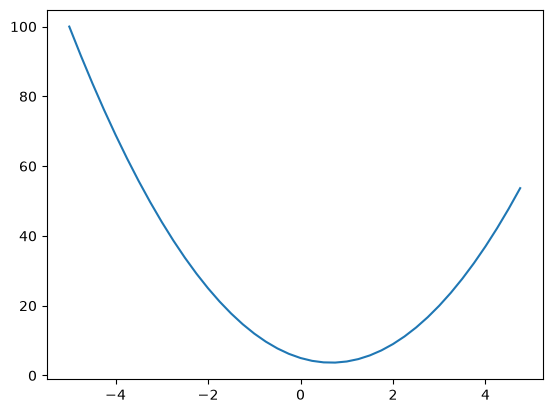

In [147]:
plt.plot(xs,ys)

In [148]:
#trying to find the derivative of the above expression

h=0.0001
x=5.0
(f(x+h) - f(x)) / h

26.000299999964227

In [149]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [150]:
h=0.001

a=2.0
b=-3.0
c=10.0

d1=a*b+c
a+=h
d2=a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.997
slope -3.0000000000001137


In [151]:
class Value:

    def __init__(self,data, _children=(), _op=(), label=()):
        self.data=data
        self.grad=0.0
        self._prev=set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out=Value(self.data+other.data, (self,other), '+')
        return out
    
    def __mul__(self,other):
        out=Value(self.data*other.data, (self,other), '*')
        return out

a = Value(20.0, label='a')
b=Value(3.0, label='b')
c= Value(5.0, label='c')
e=a*b; e.label='e'
d=e+c; d.label='d'
f=Value(-2.0,label='f')
L=d*f; L.label='L'
print("Addition", a+b)
print("Multiplication", a*b)
L

Addition Value(data=23.0)
Multiplication Value(data=60.0)


Value(data=-130.0)

In [159]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

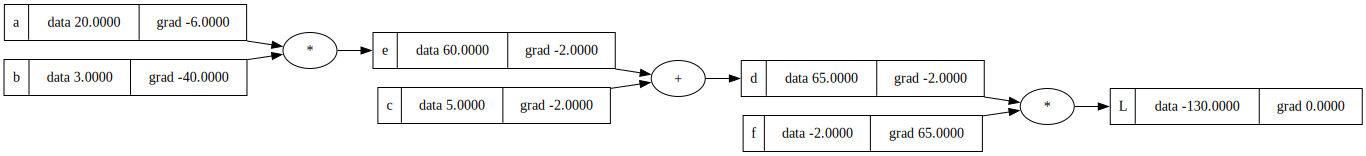

In [160]:
draw_dot(L)

### The Above process depicts a forward pass or forward propogation, where each label a,b,c,etc might represent model weights. Now the final output L is the output of the forward propogation on which we will perform derivatives to do the backpropogation with respect to each variable and store it in a different label/data class.

In [154]:
d.grad=-2.0
f.grad=65.0

In [162]:
def backprop():
    h=0.001

    a = Value(20.0, label='a')
    b=Value(3.0, label='b')
    c= Value(5.0, label='c')
    e=a*b; e.label='e'
    d=e+c; d.label='d'
    f=Value(-2.0,label='f')
    L=d*f; L.label='L'
    L1= L.data

    a = Value(20.0 + h, label='a')
    a.data+=h
    b=Value(3.0, label='b')
    c= Value(5.0, label='c')
    e=a*b; e.label='e'
    d=e+c; d.label='d'
    f=Value(-2.0,label='f')
    L=d*f; L.label='L'
    L2= L.data + h

    print((L2-L1)/h)

backprop()

-10.99999999999568


## For Backpropogation

#d = c+e
#dd/dc => (f(x+h)-f(x))/h
#((c+h+e)-(c+e))/h
#h/h = 1.0

#Therefore: dd/dc = 1.0 and dd/de = 1.0

So now for backpropogation, we need the dl/dc and dl/de but we know only dd/dc, dd/de and dl/dd. Therefore we now use chain rule of calculus

### Chain Rule: dz/dx = dz/dy * dy/dx


So now we do: 
dl/dc = (dl/dd) * (dd/dc)
dl/de = (dl/dd) * (dd/de)



In [156]:
c.grad=-2.0
e.grad=-2.0

de/da=b

dl/da = (dl/de) * (de/da)
dl/da=-2*3 = -6


similarly dl/db = dl/de * de/db = -2 * 20 = -40

In [158]:
a.grad=-6
b.grad=-40